In [23]:
import torch
import matplotlib.pyplot as plt

torch.manual_seed(42)

In [24]:
# Class -1
X0 = torch.randn(50, 2) + torch.tensor([-2., -2.])

# Class +1
X1 = torch.randn(50, 2) + torch.tensor([2., 2.])

X = torch.cat([X0, X1], dim=0)

y = torch.cat([
    -torch.ones(50),
     torch.ones(50)
]).unsqueeze(1)

print(X.shape)
print(y.shape)

torch.Size([100, 2])
torch.Size([100, 1])


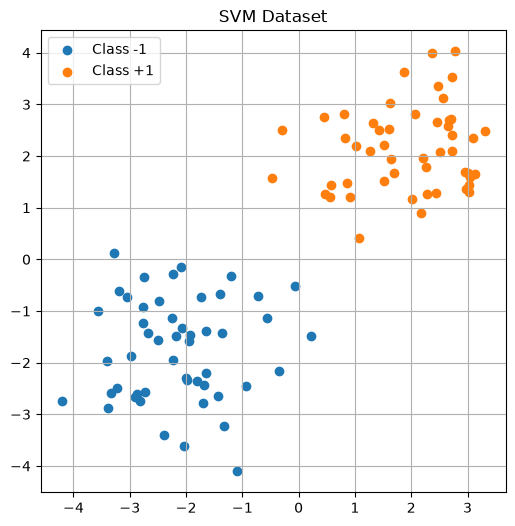

In [25]:
plt.figure(figsize=(6,6))

plt.scatter(
    X0[:,0],
    X0[:,1],
    label="Class -1"
)

plt.scatter(
    X1[:,0],
    X1[:,1],
    label="Class +1"
)

plt.grid(True)
plt.legend()
plt.title("SVM Dataset")
plt.show()

In [26]:
class LinearSVM(torch.nn.Module):

    def __init__(self):

        super().__init__()

        self.linear = torch.nn.Linear(2,1)

    def forward(self,x):

        return self.linear(x)

In [27]:
def hinge_loss(out_puts,labels):

    loss = torch.clamp(1 - labels * out_puts, min = 0)

    return loss.mean()

In [28]:
model = LinearSVM()

optimizer = torch.optim.SGD(model.parameters(),lr = 0.01)

# certireion = torch.nn.MSELoss()

In [29]:
epochs = 1000

for epoch in range(epochs):

    outputs = model(X)

    loss = hinge_loss(outputs,y)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    if epoch % 100 == 0:
        print(
            f"Epoch {epoch} | Loss: {loss.item():.4f}"
        )

Epoch 0 | Loss: 0.0615
Epoch 100 | Loss: 0.0294
Epoch 200 | Loss: 0.0183
Epoch 300 | Loss: 0.0138
Epoch 400 | Loss: 0.0110
Epoch 500 | Loss: 0.0081
Epoch 600 | Loss: 0.0065
Epoch 700 | Loss: 0.0055
Epoch 800 | Loss: 0.0053
Epoch 900 | Loss: 0.0052


In [30]:
with torch.no_grad():
    
    outputs = model(X)
    predictions = torch.sign(outputs)

In [31]:
accuracy = (predictions == y).float().mean()

print(f"Accuracy: {accuracy*100:.2f}%")

Accuracy: 100.00%


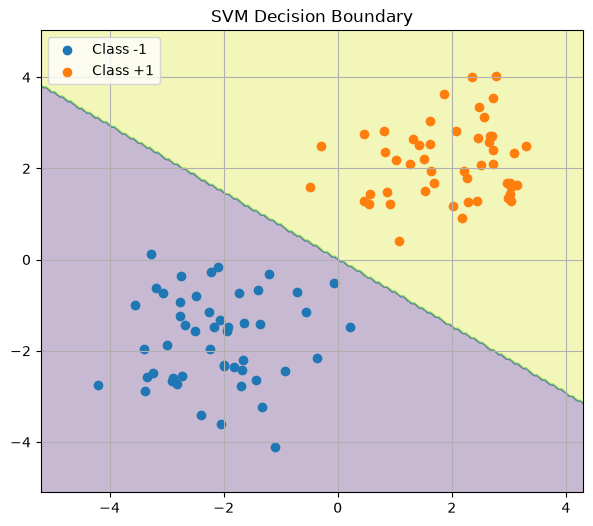

In [32]:
with torch.no_grad():

    x_min = X[:,0].min()-1
    x_max = X[:,0].max()+1

    y_min = X[:,1].min()-1
    y_max = X[:,1].max()+1

    xx,yy = torch.meshgrid(
        torch.linspace(x_min,x_max,200),
        torch.linspace(y_min,y_max,200),
        indexing="ij"
    )

    grid = torch.stack(
        [xx.reshape(-1),yy.reshape(-1)],
        dim=1
    )

    Z = torch.sign(model(grid))
    Z = Z.reshape(xx.shape)

plt.figure(figsize=(7,6))

plt.contourf(
    xx.numpy(),
    yy.numpy(),
    Z.numpy(),
    alpha=0.3
)

plt.scatter(
    X0[:,0],
    X0[:,1],
    label="Class -1"
)

plt.scatter(
    X1[:,0],
    X1[:,1],
    label="Class +1"
)

plt.grid(True)
plt.legend()
plt.title("SVM Decision Boundary")

plt.show()